<a href="https://colab.research.google.com/github/anum-codes/machine-learning/blob/main/sales_prediction_on_ads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [93]:
df = pd.read_csv("/content/drive/MyDrive/Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [94]:
df = df.drop(columns=['Unnamed: 0'])
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


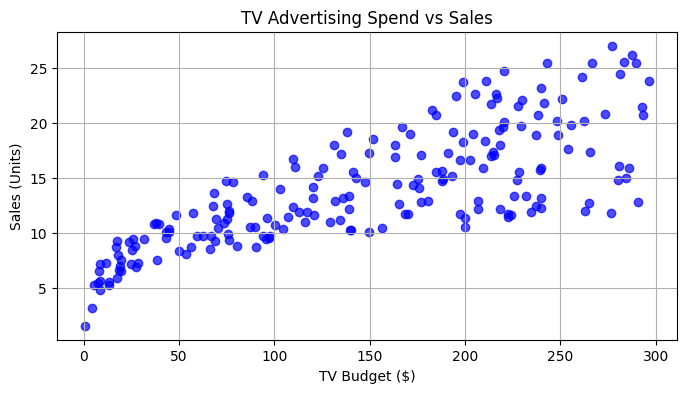

In [95]:
plt.figure(figsize=(8, 4))
plt.scatter(df['TV'], df['Sales'], color='blue', alpha=0.7)
plt.title('TV Advertising Spend vs Sales')
plt.xlabel('TV Budget ($)')
plt.ylabel('Sales (Units)')
plt.grid(True)
plt.show()

In [96]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [99]:
y_pred = model.predict(X_test)

In [100]:
print(f"Intercept (Base Sales): {model.intercept_:.4f}")
print(f"Coefficients (TV, Radio, Newspaper): {model.coef_}")

Intercept (Base Sales): 2.9791
Coefficients (TV, Radio, Newspaper): [0.04472952 0.18919505 0.00276111]


In [101]:
train_r2 = r2_score(y_train, model.predict(X_train))
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Test R^2 Score:     {test_r2:.4f}")
print(f"Test Mean Squared Error (MSE): {test_mse:.4f}")

Training R^2 Score: 0.8957
Test R^2 Score:     0.8994
Test Mean Squared Error (MSE): 3.1741


In [102]:
comparison_df = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred})
print(comparison_df.head(10))

     Actual Sales  Predicted Sales
95           16.9        16.408024
15           22.4        20.889882
30           21.4        21.553843
158           7.3        10.608503
128          24.7        22.112373
115          12.6        13.105592
69           22.3        21.057192
170           8.4         7.461010
174          11.5        13.606346
45           14.9        15.155070


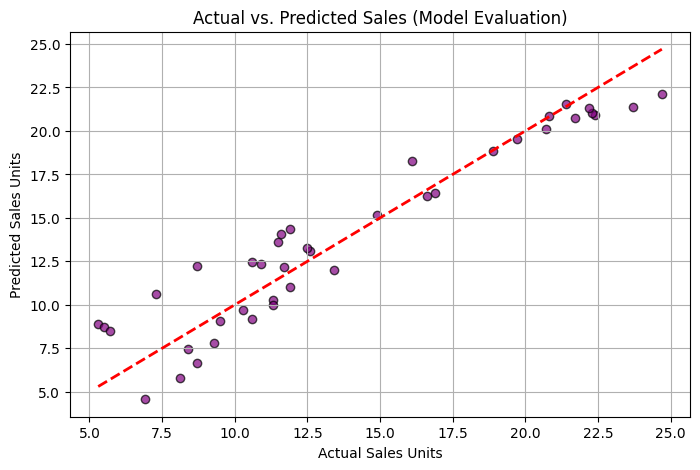

In [103]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='purple', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Sales (Model Evaluation)')
plt.xlabel('Actual Sales Units')
plt.ylabel('Predicted Sales Units')
plt.grid(True)
plt.show()

In [104]:
def predict_custom_budget(tv_budget, radio_budget, newspaper_budget):
    """Predicts sales based on specified TV, Radio, and Newspaper budgets."""
    custom_data = pd.DataFrame([{
        'TV': tv_budget,
        'Radio': radio_budget,
        'Newspaper': newspaper_budget
    }])
    return model.predict(custom_data)[0]

In [105]:
sample_sales = predict_custom_budget(150.0, 50.0, 10.0)
print(f"\nPredicted Sales for custom budget ($150 TV, $50 Radio, $10 News): {sample_sales:.2f} units")


Predicted Sales for custom budget ($150 TV, $50 Radio, $10 News): 19.18 units
